# Image Colorization using Deep Learning

This notebook presents a deep learning-based approach for automatic image colorization.

The objective is to predict plausible color information for grayscale images using convolutional neural networks.

This work is inspired by:

**"Colorful Image Colorization" — Zhang et al., ECCV 2016**

## Problem Statement

Image colorization is an inherently ill-posed problem because multiple color mappings can exist for the same grayscale image.

The goal is to learn a mapping:

Grayscale Image (L channel) → Color Components (AB channels)

The model predicts chrominance values while preserving luminance from the input.

## Colorization Pipeline

The complete workflow of the system:


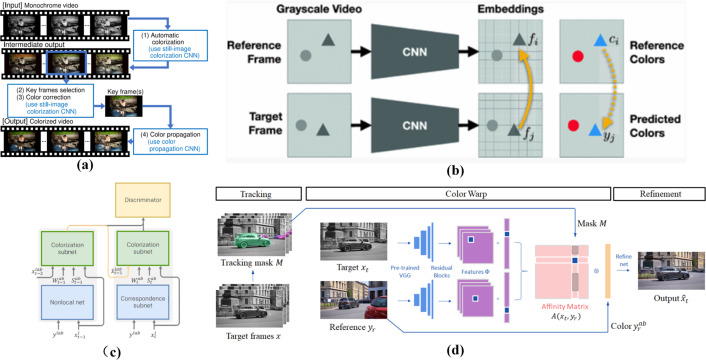
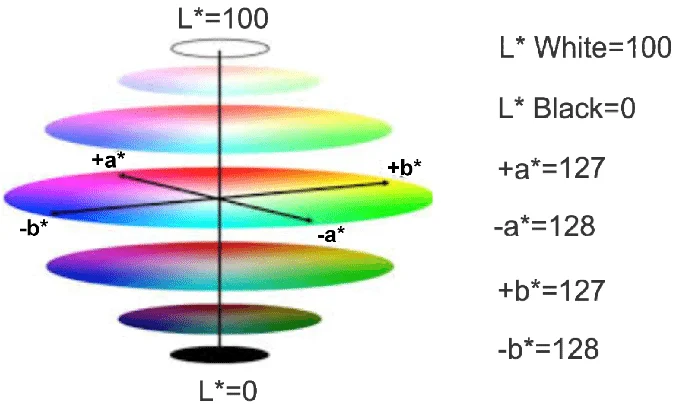

The process involves:

1. Convert RGB image to LAB color space  
2. Extract L channel (grayscale input)  
3. Predict AB channels using neural network  
4. Combine L + AB  
5. Convert back to RGB image  

## Dataset

Training deep learning models for colorization requires large-scale image datasets.

Common datasets include:

- ImageNet
- COCO Dataset
- Oxford-IIIT Pets Dataset

These datasets provide diverse scenes, objects, and textures, allowing the model to generalize color predictions effectively.

Due to computational limitations, this notebook demonstrates the pipeline using a sample image rather than full dataset training.

However, in real-world scenarios, thousands of images are required for high-quality results.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Input
from tensorflow.keras.models import Model

## LAB Color Space

LAB color space separates luminance and color information:

- L channel: Lightness (grayscale)
- A channel: Green to Red
- B channel: Blue to Yellow

This separation makes it ideal for colorization tasks, as the model only needs to predict color components.

In [ ]:
image = cv2.imread("sample.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

## Conversion to LAB Space

The RGB image is converted into LAB format.  
The L channel is used as input to the model, while the AB channels serve as ground truth.

In [ ]:
lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

L = lab[:, :, 0]
AB = lab[:, :, 1:]

plt.imshow(L, cmap="gray")
plt.title("Grayscale Input (L Channel)")
plt.axis("off")

## Preprocessing

The data is normalized and reshaped to match the neural network input format.

This ensures stable training and efficient computation.

In [ ]:
L = L / 255.0
AB = AB / 255.0

L = L.reshape(1, L.shape[0], L.shape[1], 1)
AB = AB.reshape(1, AB.shape[0], AB.shape[1], 2)

## Model Architecture

The model is a convolutional neural network designed to map grayscale inputs to color outputs.

Architecture overview:

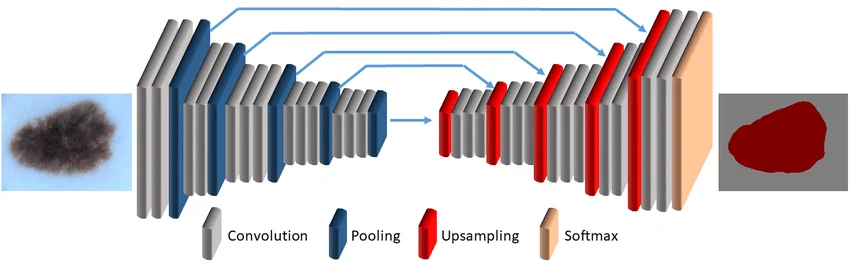
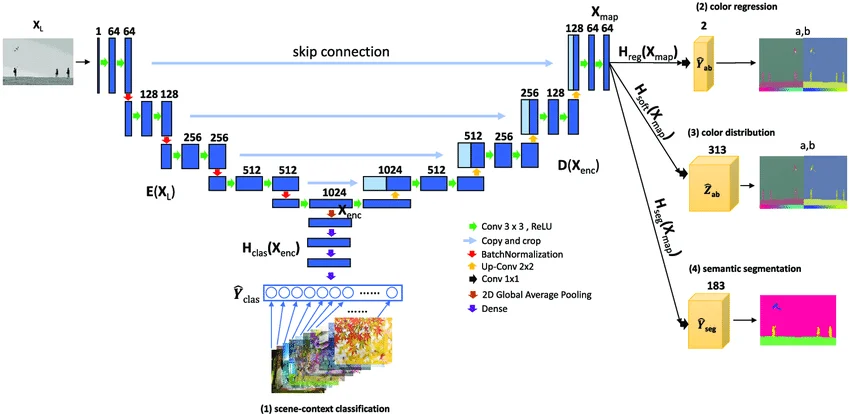

The network consists of:

- Convolutional layers for feature extraction  
- Non-linear activations for learning complex mappings  
- Output layer predicting AB color channels  

In [ ]:
def build_model():
    inp = Input((256, 256, 1))

    x = Conv2D(64, 3, padding="same", activation="relu")(inp)
    x = Conv2D(128, 3, padding="same", activation="relu")(x)
    x = Conv2D(128, 3, padding="same", activation="relu")(x)

    out = Conv2D(2, 1, activation="sigmoid")(x)

    return Model(inp, out)

model = build_model()
model.summary()

## Training Process

The model is trained using pairs of grayscale and color images.

Loss function:
- Mean Squared Error (MSE)

Optimizer:
- Adam

Full training requires large datasets and GPU acceleration.

In [ ]:
model.compile(optimizer="adam", loss="mse")

## Training Execution

Training is computationally intensive and is not executed in this notebook.

Example training command:

model.fit(X_train, Y_train, epochs=50)

In practical implementations, pretrained models are used to achieve better performance efficiently.

## Inference

The trained model predicts AB channels from the grayscale input.

These predicted values are combined with the L channel to reconstruct the final color image.

In [ ]:
pred_ab = model.predict(L)

lab_out = np.concatenate([L[0] * 255, pred_ab[0] * 255], axis=-1).astype("uint8")

colorized = cv2.cvtColor(lab_out, cv2.COLOR_LAB2RGB)

plt.imshow(colorized)
plt.title("Colorized Output")
plt.axis("off")

## Results

The model produces a colorized version of the grayscale image.

The quality depends on:
- Dataset size
- Model architecture
- Training duration

Pretrained models significantly improve realism and accuracy.

## Conclusion

This notebook demonstrates:

- LAB color space transformation
- Neural network-based color prediction
- Image reconstruction pipeline
- Practical limitations of training

For deployment, pretrained models provide efficient and high-quality results.

## References

- Zhang, R., Isola, P., & Efros, A. A. (2016). Colorful Image Colorization. ECCV.
- OpenCV Deep Neural Network (DNN) Module
- COCO Dataset